## Setup

Importing the necessary Python libraries for data analysis, data manipulation and visualisation.
- Pandas: data analysis and data manipulation  
- Matplotlib (plt): data visualization  
- Matplotlib ticker: axis formatting and styling

In [335]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Data Loading

Loading the cleaned dataset for analysis.

In [338]:
df = pd.read_csv(r"C:\Users\kroze\cleaned_ecommerce_data.csv")
df

,order_id,order_date,customer_name,region,city,category,sub_category,product_name,quantity,unit_price,discount,sales,profit,payment_mode,year,month,year_month
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294.0,5.0,68958.6,10525.09,Debit Card,2024,10,2024-10
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165.0,20.0,33732.0,6299.66,Debit Card,2025,8,2025-08
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876.0,20.0,207603.2,19850.27,Credit Card,2023,11,2023-11
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320.0,15.0,158610.0,36311.02,UPI,2025,5,2025-05
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037.0,10.0,45033.3,9050.04,Debit Card,2025,1,2025-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671.0,0.0,182013.0,11853.15,Debit Card,2024,6,2024-06
4996,14997,2024-12-22,Aaina Chander,North,Jaipur,Toys,Doll,Doll Nulla,5,70048.0,0.0,350240.0,31237.23,Credit Card,2024,12,2024-12
4997,14998,2025-04-15,Dhanush Gara,South,Bangalore,Beauty,Lipstick,Lipstick Eaque,1,42162.0,15.0,35837.7,7827.50,Debit Card,2025,4,2025-04
4998,14999,2024-07-08,Divyansh Malhotra,East,Kolkata,Electronics,Smartwatch,Smartwatch Adipisci,4,13568.0,10.0,48844.8,6603.86,Credit Card,2024,7,2024-07


In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       5000 non-null   int64  
 1   order_date     5000 non-null   object 
 2   customer_name  5000 non-null   object 
 3   region         5000 non-null   object 
 4   city           5000 non-null   object 
 5   category       5000 non-null   object 
 6   sub_category   5000 non-null   object 
 7   product_name   5000 non-null   object 
 8   quantity       5000 non-null   int64  
 9   unit_price     5000 non-null   float64
 10  discount       5000 non-null   float64
 11  sales          5000 non-null   float64
 12  profit         5000 non-null   float64
 13  payment_mode   5000 non-null   object 
 14  year           5000 non-null   int64  
 15  month          5000 non-null   int64  
 16  year_month     5000 non-null   object 
dtypes: float64(4), int64(4), object(9)
memory usage: 664

# Convert order_date to datetime format

In [404]:
df['order_date'] = pd.to_datetime(df['order_date'])

## Monthly Revenue Analysis

This section analyzes how revenue evolves over time to identify trends and seasonality.

In [400]:
summary_revenue = df.groupby('year_month', as_index=False).agg(
    total_monthly_revenue = ('sales', 'sum'),
    total_monthly_orders = ('sales', 'count'),
    unique_days = ('order_date', 'nunique')
).sort_values(by='year_month', ascending=True)
summary_revenue

,year_month,total_monthly_revenue,total_monthly_orders,unique_days
0,2023-10,21307522.20,202,28
1,2023-11,22040269.20,204,29
2,2023-12,20624240.25,195,31
3,2024-01,21477241.40,222,31
4,2024-02,19853396.50,196,29
5,2024-03,21571015.35,199,31
6,2024-04,22214781.10,214,30
7,2024-05,24744786.55,217,31
8,2024-06,21368962.50,201,30
9,2024-07,24019283.90,220,31


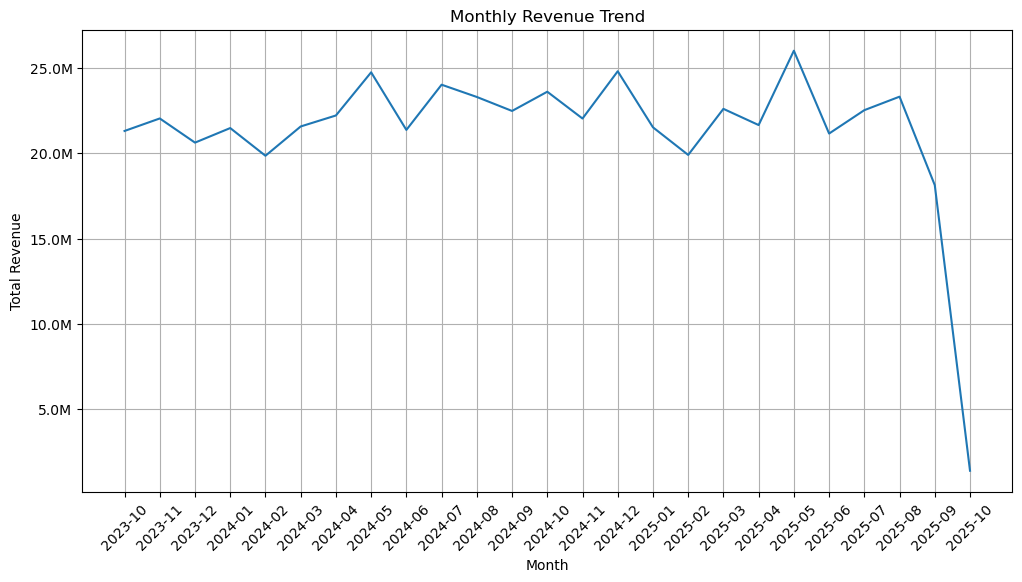

In [345]:
plt.figure(figsize=(12,6))
plt.plot(summary_revenue['year_month'],summary_revenue['total_monthly_revenue'])
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()


## Insight

Monthly changes are approximately ~15%, except for the last month, which shows a significant drop due to incomplete data (only 3 days recorded).

## Monthly Profit Analysis

This section analyzes how profit evolves over time to understand business performance.

In [348]:
summary_profit = df.groupby('year_month', as_index=False )['profit'].sum().rename(columns={'profit':'total_monthly_profit'}).sort_values(by='year_month', ascending=True)
summary_profit

,year_month,total_monthly_profit
0,2023-10,3106231.10
1,2023-11,3387740.08
2,2023-12,2989330.92
3,2024-01,3104253.86
4,2024-02,2941448.82
5,2024-03,3235674.53
6,2024-04,3241579.85
7,2024-05,3692958.55
8,2024-06,3261199.09
9,2024-07,3486946.19


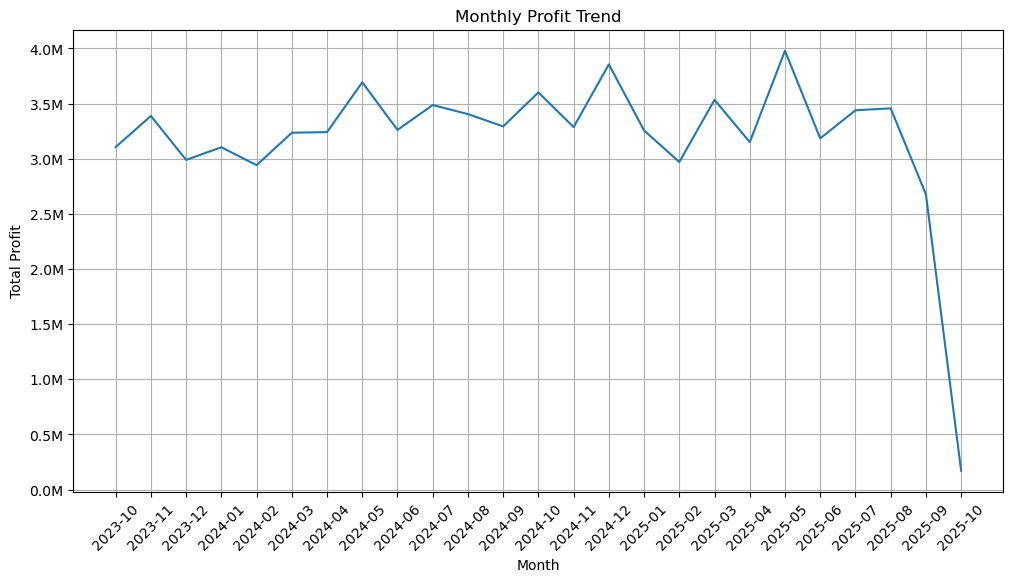

In [350]:
plt.figure(figsize=(12,6))
plt.plot(summary_profit['year_month'],summary_profit['total_monthly_profit'])
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Insight

Profit follows a similar monthly trend to revenue, showing consistent performance over time. The only exception is the final month, where the drop is due to incomplete data (only 3 days recorded).

## Revenue vs Profit Comparison

This section compares revenue and profit trends to evaluate business efficiency and margins.

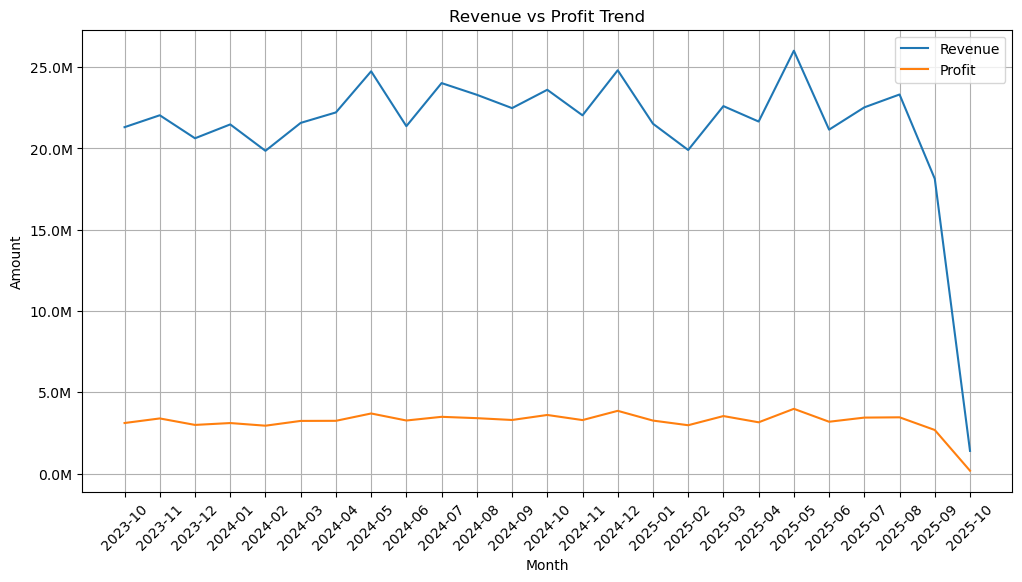

In [353]:
plt.figure(figsize=(12,6))
plt.plot(summary_revenue['year_month'],summary_revenue['total_monthly_revenue'], label='Revenue')
plt.plot(summary_profit['year_month'],summary_profit['total_monthly_profit'], label='Profit')
plt.title('Revenue vs Profit Trend')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Insight

Revenue and profit follow a similar trend over time, indicating stable business performance.  
The drop in the final period is due to incomplete data for the last month.

## Top Customers Analysis

This section explores the customers who generate the most revenue and their purchasing behavior.

In [356]:
top_customers = df.groupby('customer_name', as_index=False).agg(
    total_revenue= ('sales','sum'),
    total_orders = ('sales', 'count'),
    avg_revenue = ('sales', 'mean')
).sort_values(by='total_revenue',ascending=False).head(10)
top_customers

,customer_name,total_revenue,total_orders,avg_revenue
109,Aaryahi Madan,650151.9,3,216717.30
2245,Kimaya Vala,490935.0,2,245467.50
707,Badal Rao,485698.0,2,242849.00
186,Adira Dhingra,479389.0,2,239694.50
4109,Sumer Mann,469937.0,2,234968.50
2780,Nayantara Majumdar,459763.5,2,229881.75
3141,Prerak Shere,451862.4,2,225931.20
750,Bhamini Sane,441410.6,2,220705.30
3754,Samarth Wagle,427715.5,2,213857.75
575,Arhaan Basu,426563.6,2,213281.80


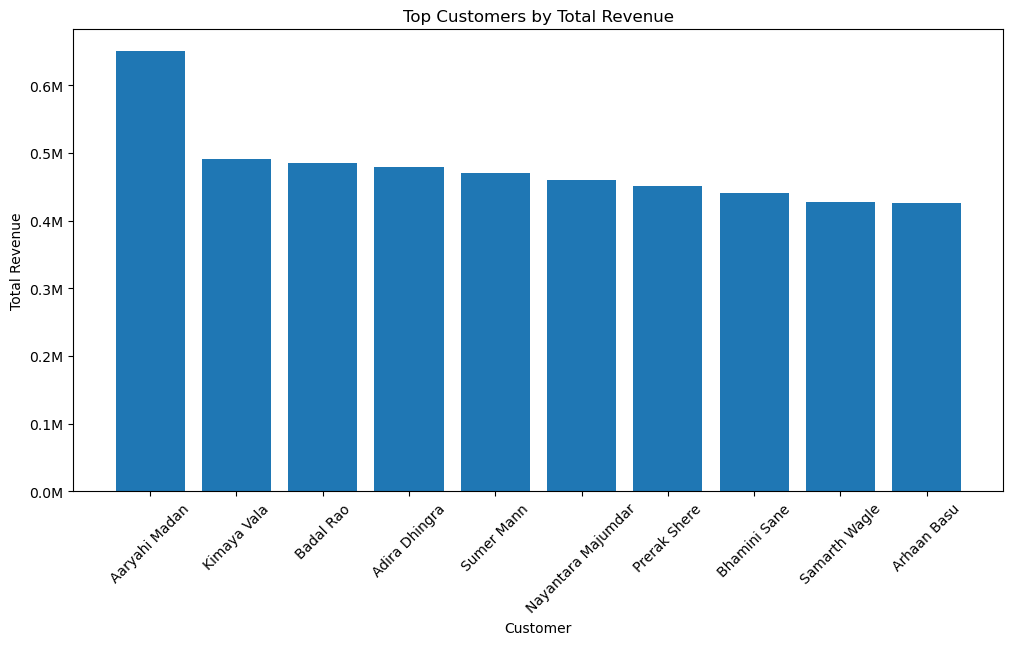

In [358]:
plt.figure(figsize=(12,6))
plt.bar(top_customers['customer_name'],top_customers['total_revenue'])
plt.title('Top Customers by Total Revenue')
plt.xlabel('Customer')
plt.ylabel('Total Revenue')
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.xticks(rotation=45)
plt.show()

## Insight

The top customer stands out with significantly higher revenue (~650k), indicating a high-value client.
The remaining top customers show similar revenue levels (420k-500k), suggesting a relatively balanced customer base.

## Top Products Analysis

This section shows the top revenue generating products and their categories.

## top_products = df.groupby(['product_name', 'category'], as_index=False).agg(
    total_revenue = ('sales','sum'),
    total_quantity = ('quantity', 'sum'),
    avg_revenue = ('sales','mean'),
    total_orders = ('sales','count')
).sort_values(by='total_revenue',ascending=False).head(10).round(2)
top_products

###### top_products['label'] = top_products['product_name'] + "\n(" + top_products['category'] + ")"
plt.figure(figsize=(12,6))
plt.bar(top_products['label'],top_products['total_revenue'])
plt.title('Top Products by Total Revenue')
plt.xlabel('Product Name (Category)')
plt.ylabel('Total Revenue')
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.xticks(rotation=45)
plt.show()

## Insight

Electronics dominates the top revenue products, indicating strong demand in high-value technical goods.
Some products, such as Men's Wear Voluptatibus, generate high revenue with very few orders, suggesting high-value, low-frequency purchases.
Overall, revenue is distributed across multiple categories, indicating a diversified product portfolio rather than dependence on a single category.

## Sub-Category Analysis

This section explores the best-performing sub-categories in terms of revenue, order volume, and quantity sold across different categories.

In [368]:
sub_categories = df.groupby(['sub_category','category'] ,as_index=False).agg(
    total_revenue = ('sales', 'sum'),
    avg_revenue = ('sales', 'mean'),
    total_orders = ('sales', 'count'),
    total_quantity = ('quantity', 'sum')
).sort_values(by='total_revenue', ascending=False).head(10).round(2)
sub_categories

,sub_category,category,total_revenue,avg_revenue,total_orders,total_quantity
39,Sofa,Furniture,15185544.25,124471.67,122,411
22,Lamp,Home Decor,14767580.20,126218.63,117,375
43,Tennis Racket,Sports,12934015.25,122019.01,106,327
48,Women's Wear,Clothing,12646602.90,107174.60,118,340
16,Fiction,Books,12376112.80,122535.77,101,311
29,Non-Fiction,Books,12219033.75,107184.51,114,324
2,Bed,Furniture,12211588.60,104372.55,117,340
20,Juicer,Kitchen,12194033.75,106035.08,115,342
19,Headphones,Electronics,12058508.60,125609.46,96,305
17,Football,Sports,11779009.10,98158.41,120,324


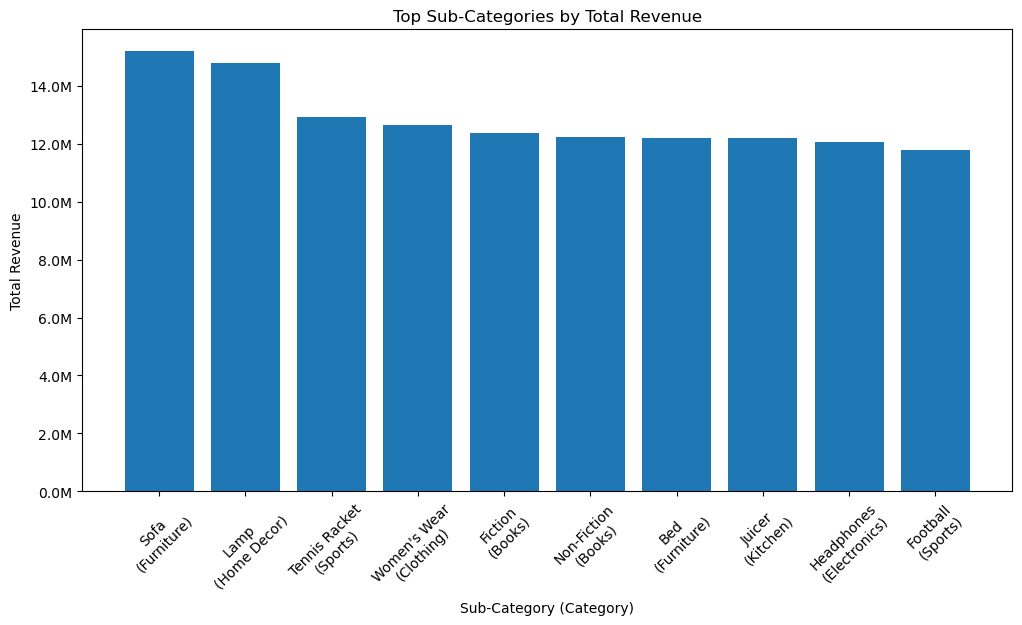

In [373]:
sub_categories['label'] = sub_categories['sub_category'] + "\n(" + sub_categories['category'] + ")"
plt.figure(figsize=(12,6))
plt.bar(sub_categories['label'],sub_categories['total_revenue'])
plt.title('Top Sub-Categories by Total Revenue')
plt.xlabel('Sub-Category (Category)')
plt.ylabel('Total Revenue')
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.xticks(rotation=45)
plt.show()


## Insight

Furniture and Home Decor sub-categories (Sofa, Lamp, Bed) are the primary revenue drivers, indicating strong demand in home-related products.
Sports-related products such as Tennis Racket and Football also contribute significantly, but show different dynamics: Tennis Racket has higher average revenue per order, while Football is driven by higher order volume.
Overall, revenue is well diversified across categories, with no single dependency dominating the business.

## Final Insights

- Revenue is generally stable over time, with no strong long-term drops or spikes.
- The final month shows a sharp drop because it contains incomplete data, with only 3 days recorded.
- Profit follows a similar pattern to revenue, showing consistent performance.
- Customers are fairly well distributed. A few customers generate higher revenue, but most contribute in a balanced way.
- At the product level, revenue is spread across multiple products, so the business does not depend on just a few items.
- The strongest categories are Furniture, Home Decor, and Sports. Products like Sofa, Lamp, and Tennis Racket are the top contributors.
- There is a mix of high-volume products and high-value products, which shows a balanced sales structure.

## Key Takeaway

Overall, the business looks stable and diversified, with no strong dependency on a single product, customer, or category.

## Recommendation

- Focus on scaling high-performing sub-categories such as Furniture and Sports.
- Investigate high-value low-frequency products for premium strategy opportunities.
- Strengthen customer retention for top revenue-generating clients.

# Exporting data for Power BI

In [406]:
summary_profit.to_csv('summary_profit.csv', index=False)
summary_revenue.to_csv('summary_revenue.csv', index=False)
top_customers.to_csv('top_customers.csv', index=False)
top_products.to_csv('top_products.csv', index=False)
sub_categories.to_csv('sub_categories.csv', index=False)